In [8]:
import torch
import torch.nn as nn
import torch.autograd as autograd
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, utils
import matplotlib.pyplot as plt
from pathlib import Path

In [9]:
# Base directories (your cwd is C:\Users\ADVAIT\Desktop\CV CASE 2)
BASE_DIR  = Path.cwd()
DATA_DIR  = BASE_DIR / "final_processed_data" / "final_processed_data"
TRAIN_DIR = DATA_DIR / "train"

print("Using training folder:", TRAIN_DIR)

Using training folder: C:\Users\ADVAIT\Desktop\CV CASE 2\final_processed_data\final_processed_data\train


#### **Data Loader**

In [11]:
# 2) DataLoader
img_size = 64
batch_size = 64

tf = transforms.Compose([
    transforms.Resize(img_size),
    transforms.CenterCrop(img_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5,)*3, (0.5,)*3),
])

train_ds = datasets.ImageFolder(root=str(TRAIN_DIR), transform=tf)
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=4)

print("Classes:", train_ds.classes)



Classes: ['drink', 'food', 'inside', 'outside']


####  WGAN-GP Generator & Critic Architecture

In [12]:
# 3) WGAN-GP Generator & Critic
class Generator(nn.Module):
    def __init__(self, z_dim=100, img_channels=3, feature_g=64):
        super().__init__()
        self.net = nn.Sequential(
            # input: N x z_dim
            nn.Linear(z_dim, feature_g*8*4*4),
            nn.ReLU(True),
            nn.Unflatten(1, (feature_g*8, 4, 4)),
            # upsample to 8×8
            nn.ConvTranspose2d(feature_g*8, feature_g*4, 4, 2, 1), nn.ReLU(True),
            # upsample to 16×16
            nn.ConvTranspose2d(feature_g*4, feature_g*2, 4, 2, 1), nn.ReLU(True),
            # upsample to 32×32
            nn.ConvTranspose2d(feature_g*2, feature_g,   4, 2, 1), nn.ReLU(True),
            # upsample to 64×64
            nn.ConvTranspose2d(feature_g, img_channels, 4, 2, 1), nn.Tanh()
        )
    def forward(self, z):
        return self.net(z)

class Critic(nn.Module):
    def __init__(self, img_channels=3, feature_d=64):
        super().__init__()
        self.net = nn.Sequential(
            # input: N x 3 x64x64
            nn.Conv2d(img_channels, feature_d, 4, 2, 1), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feature_d,   feature_d*2, 4, 2, 1), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feature_d*2, feature_d*4, 4, 2, 1), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feature_d*4, feature_d*8, 4, 2, 1), nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(feature_d*8*4*4, 1),
        )
    def forward(self, img):
        return self.net(img)


####  Gradient Penalty

In [13]:
# 4) Gradient Penalty
def gradient_penalty(critic, real, fake, device):
    batch_size = real.size(0)
    # sample interpolation
    alpha = torch.rand(batch_size, 1, 1, 1, device=device)
    interp = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    # critic score
    crit_interp = critic(interp)
    # compute gradients w.r.t. interpolated images
    grads = autograd.grad(
        outputs=crit_interp,
        inputs=interp,
        grad_outputs=torch.ones_like(crit_interp),
        create_graph=True
    )[0]
    grads = grads.view(batch_size, -1)
    gp = ((grads.norm(2, dim=1) - 1) ** 2).mean()
    return gp


#### **Model building (WGAN) and save**

In [7]:
# 5) Training Loop (updated with device variable and model saving)

def train_wgangp(G, C, dl, z_dim, n_epochs, lr, device, 
                 critic_iters=5, lambda_gp=10):
    G, C = G.to(device), C.to(device)
    optG = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.0, 0.9))
    optC = torch.optim.Adam(C.parameters(), lr=lr, betas=(0.0, 0.9))

    for epoch in range(1, n_epochs+1):
        for i, (real_imgs, _) in enumerate(dl):
            real_imgs = real_imgs.to(device)
            bsz = real_imgs.size(0)

            # --- Train Critic ---
            for _ in range(critic_iters):
                z = torch.randn(bsz, z_dim, device=device)
                fake_imgs = G(z).detach()
                real_scores = C(real_imgs)
                fake_scores = C(fake_imgs)
                gp = gradient_penalty(C, real_imgs, fake_imgs, device)
                c_loss = fake_scores.mean() - real_scores.mean() + lambda_gp * gp

                optC.zero_grad()
                c_loss.backward()
                optC.step()

            # --- Train Generator ---
            z = torch.randn(bsz, z_dim, device=device)
            gen_imgs = G(z)
            g_loss = -C(gen_imgs).mean()

            optG.zero_grad()
            g_loss.backward()
            optG.step()

        print(f"Epoch {epoch}/{n_epochs}  C_loss: {c_loss.item():.4f}  G_loss: {g_loss.item():.4f}")

    # === Save models after training ===
    torch.save(G.state_dict(), "wgangp_generator.pth")
    torch.save(C.state_dict(), "wgangp_critic.pth")
    print("Models saved: wgangp_generator.pth, wgangp_critic.pth")

    return G, C

# Hyperparameters
z_dim = 100
lr    = 1e-4
epochs = 30

# Instantiate models
G = Generator(z_dim=z_dim)
C = Critic()

# Train
G, C = train_wgangp(G, C, train_dl, z_dim, epochs, lr, device=device)


C:\Users\ADVAIT\anaconda3\envs\tf-gpu\lib\site-packages\torch\autograd\graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 1/30  C_loss: -110.0984  G_loss: -58.6492
Epoch 2/30  C_loss: -56.3278  G_loss: -107.5435
Epoch 3/30  C_loss: -44.0936  G_loss: -59.2611
Epoch 4/30  C_loss: -33.0282  G_loss: -62.9190
Epoch 5/30  C_loss: -44.6837  G_loss: -93.9994
Epoch 6/30  C_loss: -37.4679  G_loss: -90.6009
Epoch 7/30  C_loss: -35.9158  G_loss: -49.4949
Epoch 8/30  C_loss: -31.9994  G_loss: -65.0301
Epoch 9/30  C_loss: -33.0758  G_loss: -55.5763
Epoch 10/30  C_loss: -31.8330  G_loss: -48.8154
Epoch 11/30  C_loss: -42.7224  G_loss: -64.4329
Epoch 12/30  C_loss: -35.0217  G_loss: -32.9400
Epoch 13/30  C_loss: -22.6559  G_loss: -26.5920
Epoch 14/30  C_loss: -23.1266  G_loss: -24.6982
Epoch 15/30  C_loss: -22.9257  G_loss: -27.2363
Epoch 16/30  C_loss: -24.2286  G_loss: 6.0792
Epoch 17/30  C_loss: -26.1154  G_loss: -33.6450
Epoch 18/30  C_loss: -24.7576  G_loss: -19.7462
Epoch 19/30  C_loss: -22.9226  G_loss: -8.6823
Epoch 20/30  C_loss: -20.6733  G_loss: -16.2595
Epoch 21/30  C_loss: -21.9351  G_loss: -9.7691
Epo

#### **Loading the Trained Generator and Generating a Single Sample**

In [14]:
import torch

# Instantiate the Generator (same z_dim as before)
G = Generator(z_dim=100)
G.load_state_dict(torch.load("wgangp_generator.pth", map_location=device))
G = G.to(device)
G.eval()


Generator(
  (net): Sequential(
    (0): Linear(in_features=100, out_features=8192, bias=True)
    (1): ReLU(inplace=True)
    (2): Unflatten(dim=1, unflattened_size=(512, 4, 4))
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): Tanh()
  )
)

In [15]:
device = torch.device("cpu")
G = Generator(z_dim=100)
G.load_state_dict(torch.load("wgangp_generator.pth", map_location="cpu"))
G.eval()

with torch.no_grad():
    z = torch.randn(1, 100)
    sample = G(z)
print("Sample shape:", sample.shape)  # Should be [1, 3, 64, 64]


Sample shape: torch.Size([1, 3, 64, 64])


#### **Generating and Saving 5 Sample Images from the Trained Generator**

In [16]:
from PIL import Image
import numpy as np

G = Generator(z_dim=100)
G.load_state_dict(torch.load("wgangp_generator.pth", map_location="cpu"))
G.eval()

for i in range(5):
    with torch.no_grad():
        z = torch.randn(1, 100)
        sample = G(z)
        img = sample[0].detach().cpu().numpy()
        img = np.transpose(img, (1, 2, 0))
        img = (img * 0.5) + 0.5
        img = np.clip(img, 0, 1)
        img_uint8 = (img * 255).astype(np.uint8)
        Image.fromarray(img_uint8).save(f"sample_{i+1}.png")
        print(f"Saved sample_{i+1}.png")


Saved sample_1.png
Saved sample_2.png
Saved sample_3.png
Saved sample_4.png
Saved sample_5.png


#### **Generating Fake and Real Images for IS and FID Evaluation**

In [17]:
from torchmetrics.image.inception import InceptionScore
from torchmetrics.image.fid import FrechetInceptionDistance
from torchvision import datasets, transforms
from PIL import Image
import torch
import numpy as np

In [18]:
# -- Load your 5 generated images --
# Generate 100 fake images
fake_imgs = []
for i in range(100):
    z = torch.randn(1, 100, device=device)
    with torch.no_grad():
        img = G(z).cpu()
    img = torch.nn.functional.interpolate(img, size=(299, 299), mode='bilinear', align_corners=False)
    fake_imgs.append(img)
fake_imgs = torch.cat(fake_imgs, dim=0)

# -- Load 5 real images from your validation set (for example) --
# Update this path to a folder containing real images
REAL_VAL_PATH = 'C:/Users/ADVAIT/Desktop/CV CASE 2/final_processed_data/final_processed_data/val/food'  # Or any class
real_imgs = []
import os
real_files = [os.path.join(REAL_VAL_PATH, fname) for fname in os.listdir(REAL_VAL_PATH)][:5]
for fname in real_files:
    img = Image.open(fname).convert('RGB').resize((299, 299))
    img = np.asarray(img).astype(np.float32) / 255.0
    img = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0)
    real_imgs.append(img)
real_imgs = torch.cat(real_imgs, dim=0)


**Inception Score (IS) and Frechet Inception Distance (FID)** 

In [19]:
# Inception Score
is_metric = InceptionScore(normalize=True)
is_score, is_std = is_metric(fake_imgs)
print(f"Inception Score: {is_score:.4f} ± {is_std:.4f}")

# FID (real vs. fake)
fid_metric = FrechetInceptionDistance(feature=2048, normalize=True)
fid_metric.update(real_imgs, real=True)
fid_metric.update(fake_imgs, real=False)
fid_value = fid_metric.compute()
print(f"FID: {fid_value:.4f}")


Inception Score: 1.7750 ± 0.2050
FID: 449.3847


**Generated Images:**  

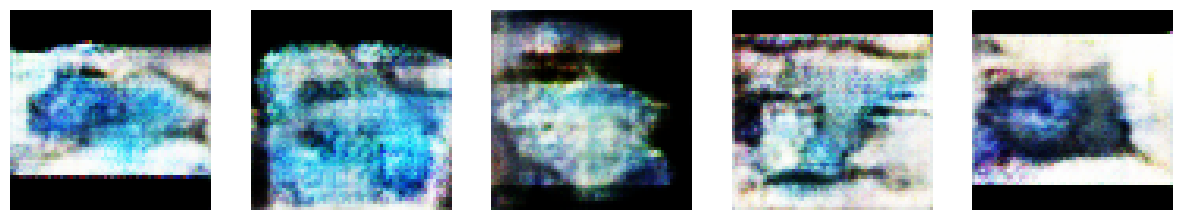

In [20]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 5, figsize=(15,3))
for i in range(5):
    img = Image.open(f"sample_{i+1}.png")
    axs[i].imshow(img)
    axs[i].axis('off')
plt.show()


Chat gpt first prompt: which libraries will be use in order to train wgan_gp model. <br>
Chat gpt last prompt: how can I improve image quality that we had saved now.